# DrivebuddyAI / Roadzen Technologies — Pav Bhaji Classification

## Data Scientist Campus Placement Challenge

**Author:** Hardik

### Objective
Classify whether an Instagram post is **Pav Bhaji** or **Not Pav Bhaji** using the supplied metadata as a **text-based ML problem**. Images are used only to establish labels; no image pixels, CNNs, OCR, or image embeddings are used.

## 1. Methodology

- Deterministic JSON-to-image filename mapping
- Data-quality and leakage investigation
- Strict removal of direct target vocabulary (`pav`, `bhaji`, and variants)
- TF-IDF word 1–2 grams + structured metadata
- Composite group split preventing owner and duplicate-caption leakage
- Group-aware 5-fold cross-validation
- Logistic Regression, Linear SVM, and Multinomial Naive Bayes comparison
- Final evaluation on an untouched grouped holdout test set

## 2. Reproducible Execution

The standalone Python script is the canonical pipeline. This notebook executes the same script and then loads the generated outputs so that the displayed metrics and figures correspond to the current corrected run.

In [1]:
from pathlib import Path
import subprocess, sys, os

ROOT = Path('..').resolve()
SRC = ROOT / 'src' / 'DrivebuddyAI_PavBhaji_Challenge.py'
DATA = ROOT / 'dataset'
OUT = ROOT / 'outputs'

cmd = [sys.executable, str(SRC), '--data-dir', str(DATA), '--output-dir', str(OUT)]
result = subprocess.run(cmd, capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError('Pipeline execution failed')


######################################################################
# STEP 1: LOAD DATA
######################################################################

######################################################################
# STEP 2: INSPECT DATA
######################################################################
DATASET INSPECTION SUMMARY
JSON records                 : 1500
Images in images/0 (Not PB)   : 269
Images in images/1 (Pav Bhaji): 183
Unique record ids             : 1495 (duplicates: 5)
Missing captions              : 1
Null location field           : 576
Video posts                   : 110

Field coverage (out of 1500 records):
  dimensions                  : 1500
  display_url                 : 1500
  edge_liked_by               : 1500
  edge_media_preview_like     : 1500
  edge_media_to_caption       : 1500
  edge_media_to_comment       : 1500
  id                          : 1500
  is_video                    : 1500
  location                    : 1500
  own

## 3. Final Dataset and Model Results

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

cv = pd.read_csv('../outputs/cv_model_comparison.csv')
mr = pd.read_csv('../outputs/model_results.csv')
fi = pd.read_csv('../outputs/feature_importance.csv')

display(cv.round(3))
display(mr.round(3))

,model,cv_accuracy_mean,cv_accuracy_std,cv_precision_mean,cv_precision_std,cv_recall_mean,cv_recall_std,cv_f1_mean,cv_f1_std,cv_roc_auc_mean,cv_roc_auc_std
0,LogisticRegression,0.622,0.037,0.528,0.037,0.678,0.082,0.591,0.044,0.688,0.040
1,LinearSVM,0.633,0.036,0.541,0.041,0.650,0.057,0.590,0.039,0.695,0.054
2,MultinomialNB,0.647,0.044,0.612,0.088,0.342,0.111,0.431,0.110,0.670,0.071


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Naive (unmasked) LogReg,0.620,0.524,0.595,0.557,0.648,0.513
1,LogisticRegression,0.598,0.500,0.541,0.519,0.630,0.497


## 4. Leakage Control

The supplied dataset contains direct target terms in almost all posts of both classes. The final model therefore uses a **strict-cleaned text field** in which direct target terms are removed rather than replaced with a placeholder.

The project also verifies zero overlap for: owner IDs, normalized captions, and the composite grouping variable.

In [3]:
import re
from pathlib import Path
log = Path('../outputs/run_log.txt').read_text(errors='ignore')
for key in ['Owner overlap between train/test:', 'Exact normalized caption overlap:', 'Composite group overlap:', 'Selected model (highest mean CV F1):']:
    for line in log.splitlines():
        if key in line:
            print(line)

Owner overlap between train/test: 0 (should be 0)
Exact normalized caption overlap: 0 (should be 0)
Composite group overlap: 0 (should be 0)
Selected model (highest mean CV F1): LogisticRegression


## 5. Model Comparison

Model selection is based on grouped cross-validated F1 rather than a single accuracy number.

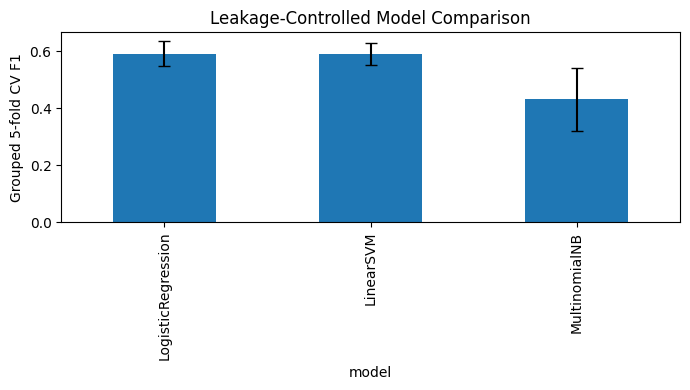

In [4]:
ax = cv.plot(x='model', y='cv_f1_mean', yerr='cv_f1_std', kind='bar', legend=False, capsize=4, figsize=(7,4))
ax.set_ylabel('Grouped 5-fold CV F1')
ax.set_title('Leakage-Controlled Model Comparison')
plt.tight_layout()
plt.show()

## 6. Feature Interpretability

In [5]:
display(fi.head(40))

,feature,coefficient,direction
0,foodlover,1.079978,Pav Bhaji
1,foodgasm,0.829432,Pav Bhaji
2,foodphotography,0.801890,Pav Bhaji
3,follow,0.748723,Pav Bhaji
4,foodstagram,0.744149,Pav Bhaji
5,foodfood,0.712926,Pav Bhaji
6,foodporn,0.654587,Pav Bhaji
7,buttery,0.637313,Pav Bhaji
8,emoji,0.616590,Pav Bhaji
9,indianstreetfood,0.601793,Pav Bhaji


## 7. Key Figures

01_class_distribution.png


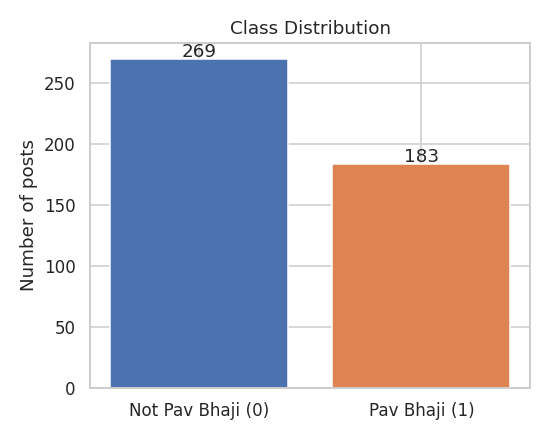

02_missing_values.png


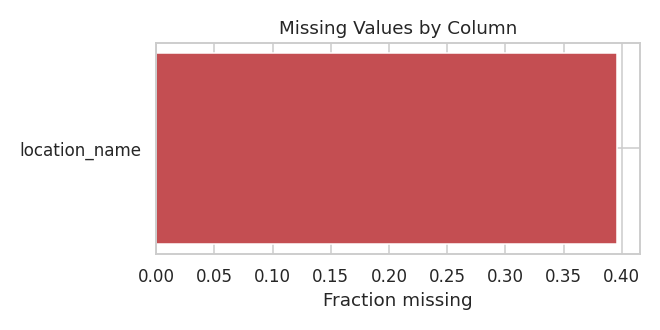

03_text_length_distribution.png


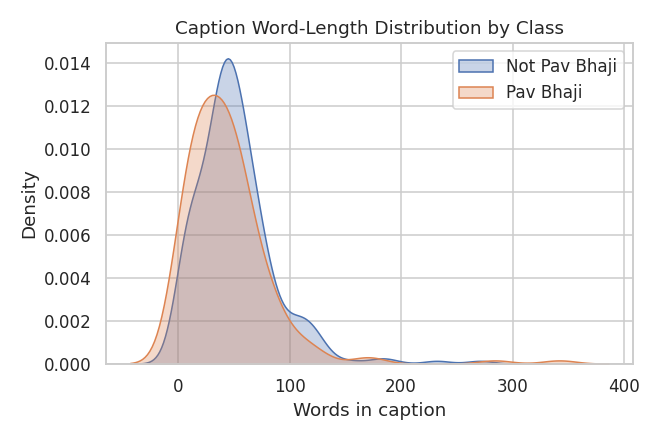

06_top_hashtags.png


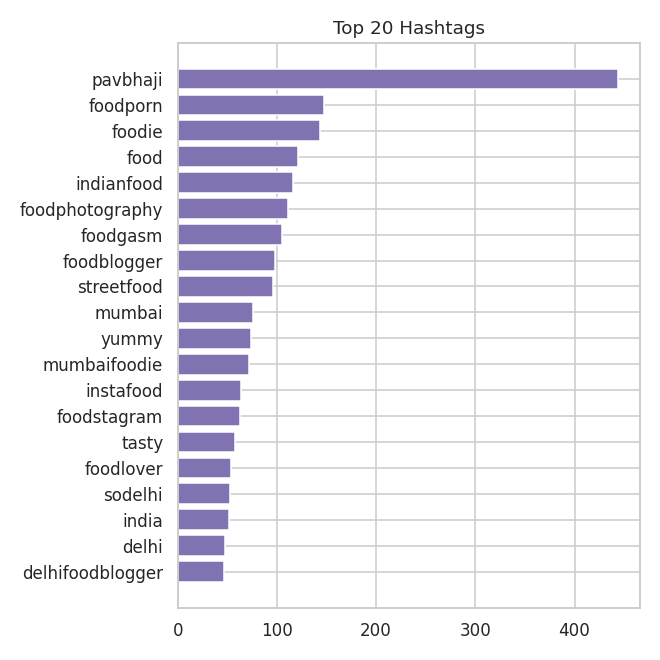

08_confusion_matrix_final.png


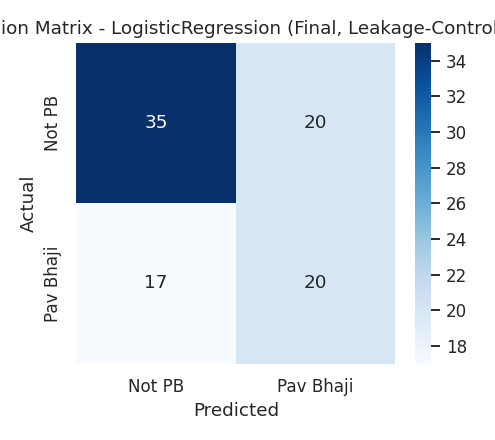

09_model_comparison_cv_f1.png


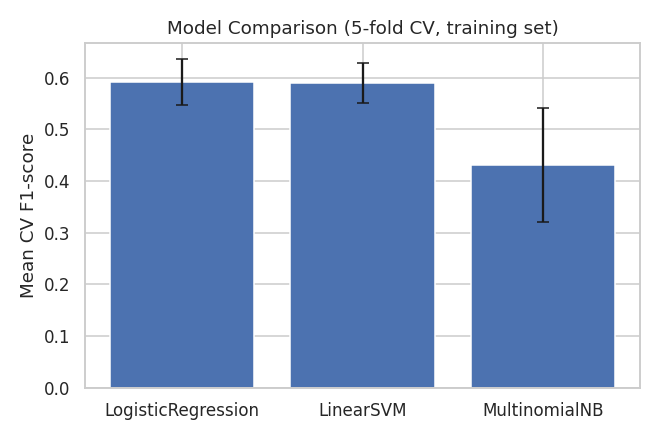

10_feature_importance.png


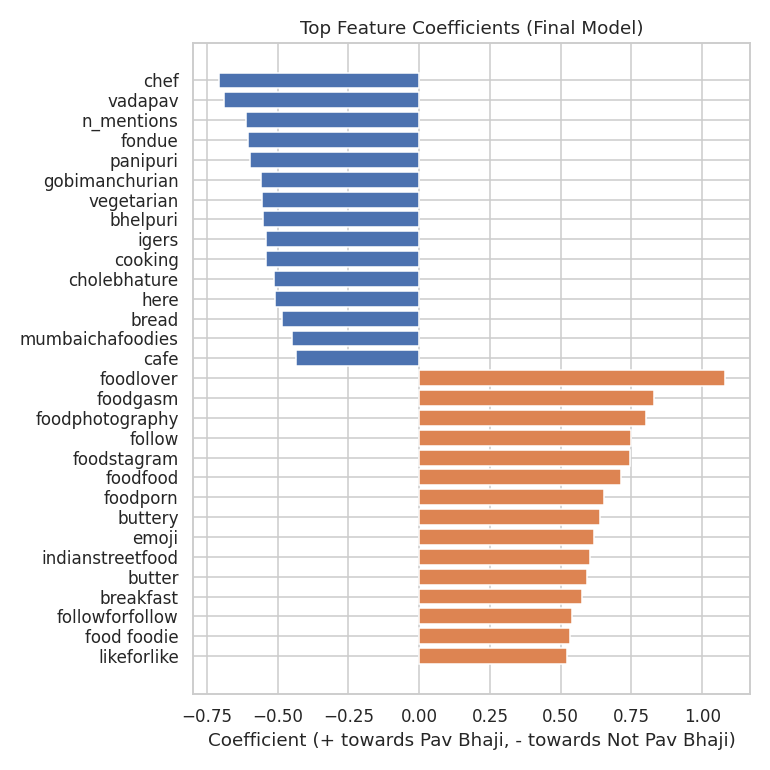

In [6]:
from IPython.display import Image, display
for fname in [
    '01_class_distribution.png',
    '02_missing_values.png',
    '03_text_length_distribution.png',
    '06_top_hashtags.png',
    '08_confusion_matrix_final.png',
    '09_model_comparison_cv_f1.png',
    '10_feature_importance.png']:
    path = Path('../outputs/figures') / fname
    if path.exists():
        print(fname)
        display(Image(filename=str(path), width=650))

## 8. Conclusion

The corrected submission uses a text-only, leakage-controlled classical ML pipeline. The final model is selected from grouped cross-validation and evaluated on a grouped holdout test set. The complete numerical results are stored under `outputs/`, and the accompanying PDF report is generated from those same results.

**Important:** Streamlit is not required by the DrivebuddyAI challenge deliverables, so no unnecessary application layer is included.